# Data Cleaning & EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from datetime import datetime


In [2]:
file_path = '../data/raw/Austin_Weather_99_23.csv'
data = pd.read_csv(file_path)
data.shape

(10354, 10)

### Missing counts & other basic stuff

In [3]:
data.isnull().sum()  # missing counts for each column

Date                         0
TempHighF                    0
TempLowF                     0
TempAvgF                     0
DewPointAvgF                 4
HumidityAvgPercent           1
sealevelpressure             0
VisibilityAvgMiles           4
PrecipitationSumInches     204
Events                    6318
dtype: int64

In [4]:
data.head()

,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


In [5]:
data.describe()

,TempHighF,TempLowF,TempAvgF,PrecipitationSumInches
count,10354.000000,10354.000000,10354.000000,10150.000000
mean,80.349189,59.701111,69.491733,0.094914
std,14.771837,14.523552,14.077261,0.360494
min,22.600000,8.200000,15.700000,0.000000
25%,71.000000,48.000000,59.200000,0.000000
50%,82.300000,62.850000,71.900000,0.000000
75%,92.000000,72.900000,81.400000,0.006000
max,110.400000,84.500000,95.100000,7.489000


### Visualization

Text(0.5, 0, 'High (in Farenheit)')

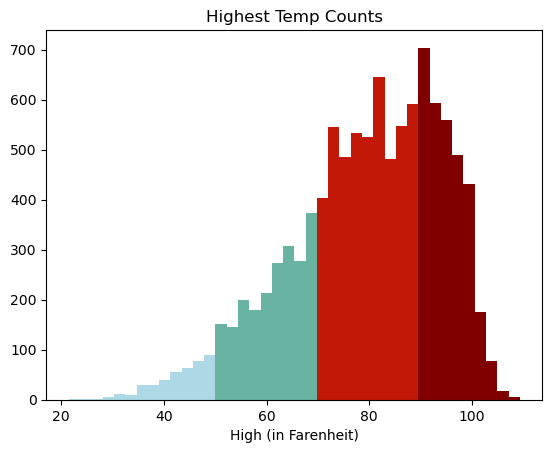

In [6]:
TempHighF, bin_edges = np.histogram(data["TempHighF"], bins=40)
cold = "lightblue"
med = "#69B3A2"
moderate = "#c21807"
extreme = "#800000"

colors = []

for bin_edge in bin_edges:
    if bin_edge < 50:
        colors.append(cold)
    elif bin_edge < 70:
        colors.append(med)
    elif bin_edge < 90:
        colors.append(moderate)
    else:
        colors.append(extreme)

plt.bar(
    bin_edges[:-1],
    TempHighF,
    width=np.diff(bin_edges),
    color=colors,
    edgecolor='none'
)

plt.title('Highest Temp Counts')
plt.xlabel('High (in Farenheit)')

### Data Cleaning

In [7]:
# Step 1: Convert Date to datetime
data['Date'] = pd.to_datetime(data['Date'])
print("\n✓ Date converted to datetime")

# Step 2: Handle Precipitation (missing = no rain)
missing_precip = data['PrecipitationSumInches'].isnull().sum()
data['PrecipitationSumInches'].fillna(0, inplace=True)
print(f"✓ Filled {missing_precip} missing precipitation values with 0")

# Step 3: Drop Events column (too many missing)
missing_events = data['Events'].isnull().sum()
print(f"✓ Dropping Events column ({missing_events} missing, {missing_events/len(data)*100:.1f}%)")
data.drop('Events', axis=1, inplace=True)

# Step 4: Interpolate small gaps
interpolate_cols = ['DewPointAvgF', 'HumidityAvgPercent', 'VisibilityAvgMiles']
for col in interpolate_cols:
    missing = data[col].isnull().sum()
    if missing > 0:
        data[col].interpolate(method='linear', inplace=True)
        data[col].fillna(method='ffill', inplace=True)
        data[col].fillna(method='bfill', inplace=True)
        print(f"✓ Interpolated {missing} missing values in {col}")

# Step 5: Sort by date
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)
print("✓ Data sorted by date")

# Final check
remaining_missing = data.isnull().sum().sum()
print(f"\n✓ Data cleaning complete! Remaining missing values: {remaining_missing}")


✓ Date converted to datetime
✓ Filled 204 missing precipitation values with 0
✓ Dropping Events column (6318 missing, 61.0%)
✓ Interpolated 4 missing values in DewPointAvgF
✓ Interpolated 1 missing values in HumidityAvgPercent
✓ Interpolated 4 missing values in VisibilityAvgMiles
✓ Data sorted by date

✓ Data cleaning complete! Remaining missing values: 0


### Calculate Heat Index

In [8]:
def calculate_heat_index(df):
    # Define T and RH columns based on the problem statement
    T = pd.to_numeric(df['TempHighF'], errors='coerce')
    RH = pd.to_numeric(df['HumidityAvgPercent'], errors='coerce')


    HI_simple = 0.5 * (T + 61.0 + ((T - 68.0) * 1.2) + (RH * 0.094))

    # Simple formula applied result, averaged with T, as specified:
    # Let's call this the "Initial HI"
    initial_HI = (T + HI_simple) / 2

    # -----------------------------------------------------------------
    # 2. Rothfusz Regression Equation
    # This is the full calculation applied only if initial_HI >= 80 F

    C1 = -42.379
    C2 = 2.04901523
    C3 = 10.14333127
    C4 = -0.22475541
    C5 = -0.00683783
    C6 = -0.05481717
    C7 = 0.00122874
    C8 = 0.00085282
    C9 = -0.00000199

    HI_rothfusz = (
        C1 + C2 * T + C3 * RH + C4 * T * RH + C5 * T**2 + C6 * RH**2 +
        C7 * (T**2) * RH + C8 * T * (RH**2) + C9 * (T**2) * (RH**2)
    )

    # -----------------------------------------------------------------
    # 3. Apply Simple or Rothfusz based on Initial HI >= 80 F

    # Start with the simple formula result (for cases < 80 F)
    final_HI = initial_HI.copy()

    # Identify where to apply the full Rothfusz calculation
    rothfusz_mask = (initial_HI >= 80)

    # Apply the Rothfusz HI calculation where the mask is True
    final_HI[rothfusz_mask] = HI_rothfusz[rothfusz_mask]

    # -----------------------------------------------------------------
    # 4. Apply Adjustments to Rothfusz HI

    # Adjustment A: RH < 13% AND 80 F <= T <= 112 F
    mask_A = (RH < 13) & (T >= 80) & (T <= 112)

    if mask_A.any():
        adjustment_A = ((13 - RH) / 4) * np.sqrt(np.abs(17 - np.abs(T - 95.)) / 17)
        # Adjustment is SUBTRACTED from HI
        final_HI[mask_A] = final_HI[mask_A] - adjustment_A[mask_A]

    # Adjustment B: RH > 85% AND 80 F <= T <= 87 F
    mask_B = (RH > 85) & (T >= 80) & (T <= 87)

    if mask_B.any():
        adjustment_B = ((RH - 85) / 10) * ((87 - T) / 5)
        # Adjustment is ADDED to HI
        final_HI[mask_B] = final_HI[mask_B] + adjustment_B[mask_B]

    return final_HI

### Date Processing & Deviation Calculations

In [9]:
# Date processing

data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['DayOfYear'] = data['Date'].dt.dayofyear
data['WeekOfYear'] = data['Date'].dt.isocalendar().week

# Calculate Deviations
avg_high_temp_by_day = data.groupby('DayOfYear')['TempHighF'].mean()
data['TempDeviation'] = data.apply(
    lambda row: row['TempHighF'] - avg_high_temp_by_day[row['DayOfYear']],
    axis = 1
)

data['HeatIndex'] =  calculate_heat_index(data)

data['TempDeviationZScore'] = stats.zscore(data['TempDeviation'])
data['TempDeviationPercentile'] = stats.norm.cdf(data['TempDeviationZScore']) * 100
condition_1 = data['TempDeviationPercentile'] >= 95
condition_2 = data['HeatIndex'] >= 105

# Use the OR operator (|) to combine them
data['significantHeat'] = condition_1 | condition_2

### Calculate Is Heat wave

In [10]:
data['isHeatWave'] = False
listofIndexes = []
last_index = data.index[-1]
for row in data.itertuples():
  if row.significantHeat and row.Index != last_index:
    listofIndexes.append(row.Index)
  else:
    if(len(listofIndexes) >= 2):
      for i in range(0, len(listofIndexes)):
        data.at[listofIndexes[i], 'isHeatWave'] = True
    listofIndexes = []

data['isHeatWave_NextDay'] = data['isHeatWave'].shift(-1)

# The last row will now have NaN (because there is no 'next day').
# We fill this last row with 0 (False) since we cannot predict beyond the dataset.
data['isHeatWave_NextDay'] = data['isHeatWave_NextDay'].fillna(0).astype(int)

data = data.drop(columns=['TempDeviation', 'TempDeviationZScore',
                          'TempDeviationPercentile', 'significantHeat'])

### Output Proccessed Data

In [11]:
# Define the output file path
output_dir = '../data/processed'
output_file_path = os.path.join(output_dir, 'Austin_Weather_Processed.csv')

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

#Save the DataFrame to CSV
data.to_csv(output_file_path, index=False)

print(f"Processed data successfully saved to: {output_file_path}")

Processed data successfully saved to: ../data/processed\Austin_Weather_Processed.csv
